<a href="https://colab.research.google.com/github/zhannakakenova/KBU-Zhanna-Spring/blob/main/2703task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests

r1 = requests.get("https://www.google.com")
r2 = requests.get("https://www.naver.com")

print(r1.headers)
print(r2.headers)

{'Date': 'Fri, 27 Mar 2026 04:02:05 GMT', 'Expires': '-1', 'Cache-Control': 'private, max-age=0', 'Content-Type': 'text/html; charset=ISO-8859-1', 'Content-Security-Policy-Report-Only': "object-src 'none';base-uri 'self';script-src 'nonce-VwojNZ-XrQwL8OIrHbgPmg' 'strict-dynamic' 'report-sample' 'unsafe-eval' 'unsafe-inline' https: http:;report-uri https://csp.withgoogle.com/csp/gws/other-hp", 'Reporting-Endpoints': 'default="//www.google.com/httpservice/retry/jserror?ei=PQHGacqGBYaOwbkPsf7V6QM&cad=crash&error=Page%20Crash&jsel=1&bver=2410&dpf=6T-WW1hu2KuHvN4scUZqVdAfdbc8L2xTZ80EuWtKHYg"', 'Accept-CH': 'Sec-CH-Prefers-Color-Scheme', 'P3P': 'CP="This is not a P3P policy! See g.co/p3phelp for more info."', 'Content-Encoding': 'gzip', 'Server': 'gws', 'X-XSS-Protection': '0', 'X-Frame-Options': 'SAMEORIGIN', 'Set-Cookie': '__Secure-STRP=AEEP7gKqkIvD4kxrTRXd5nzh3ghglboBXP-NCRMjtugTKiDsXExi7VqyOjws7lhTI87GrSHp4qgvM8amX5UN4oj6Rn7RKRjZAw; expires=Fri, 27-Mar-2026 04:07:05 GMT; path=/; domain=.

In [2]:
import requests
import pandas as pd

url = "https://jsonplaceholder.typicode.com/users"
data = requests.get(url).json()

df = pd.DataFrame(data)

# раскрываем address
address_df = pd.json_normalize(df['address'])

print(address_df)

              street      suite            city     zipcode   geo.lat  \
0        Kulas Light   Apt. 556     Gwenborough  92998-3874  -37.3159   
1      Victor Plains  Suite 879     Wisokyburgh  90566-7771  -43.9509   
2  Douglas Extension  Suite 847   McKenziehaven  59590-4157  -68.6102   
3        Hoeger Mall   Apt. 692     South Elvis  53919-4257   29.4572   
4       Skiles Walks  Suite 351      Roscoeview       33263  -31.8129   
5  Norberto Crossing   Apt. 950   South Christy  23505-1337  -71.4197   
6          Rex Trail  Suite 280       Howemouth  58804-1099   24.8918   
7   Ellsworth Summit  Suite 729       Aliyaview       45169  -14.3990   
8         Dayna Park  Suite 449  Bartholomebury  76495-3109   24.6463   
9    Kattie Turnpike  Suite 198     Lebsackbury  31428-2261  -38.2386   

     geo.lng  
0    81.1496  
1   -34.4618  
2   -47.0653  
3  -164.2990  
4    62.5342  
5    71.7478  
6    21.8984  
7  -120.7677  
8  -168.8889  
9    57.2232  


In [11]:
url = "https://jsonplaceholder.typicode.com/posts"
data = requests.get(url).json()

df = pd.DataFrame(data)

df_even = df[df.index % 2 == 0]

df_even.to_excel("even_posts.xlsx", index=False)

In [12]:
import os

print(os.listdir())

['.config', '.ipynb_checkpoints', 'sample_data', '.gradio', 'even_posts.xlsx']


In [13]:
from google.colab import files
files.download("even_posts.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
import gradio as gr
import requests
import pandas as pd

def get_posts(user_id):
    url = "https://jsonplaceholder.typicode.com/posts"
    params = {"userId": user_id}
    data = requests.get(url, params=params).json()
    return pd.DataFrame(data)

iface = gr.Interface(fn=get_posts, inputs="number", outputs="dataframe")
iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e16686470d7e4899c6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [14]:
from google.colab import files
uploaded = files.upload()

Saving bike_2510.csv to bike_2510.csv
Saving bike_2511.csv to bike_2511.csv
Saving bike_2512.csv to bike_2512.csv


In [15]:
df1 = pd.read_csv("bike_2510.csv", encoding="cp949")
df2 = pd.read_csv("bike_2511.csv", encoding="cp949")
df3 = pd.read_csv("bike_2512.csv", encoding="cp949")

In [16]:
df = pd.concat([df1, df2, df3], ignore_index=True)

In [17]:
print(df.shape)   # сколько строк
print(df.head())  # первые строки

(5002107, 11)
         대여일자  대여소번호                대여소 대여구분코드   성별   연령대   이용건수    운동량   탄소량  \
0  2025-10-01    739         739. 신월사거리    정기권  NaN  ~10대      1  58.63  0.51   
1  2025-10-01   1024      1024.  강동구청 앞    정기권  NaN  ~10대      1  46.08  0.42   
2  2025-10-01   1964      1964. 원메디타운 앞    정기권  NaN  ~10대      1  18.89  0.28   
3  2025-10-01   1966  1966. 한마을아파트 정문상가    정기권  NaN  ~10대      1  14.26  0.21   
4  2025-10-01   1160  1160. 양천향교역 7번출구앞    정기권  NaN  ~10대      1  12.89  0.14   

   이동거리(M)  이용시간(분)  
0  2209.88       15  
1  1790.06       15  
2  1192.45        9  
3   899.94        4  
4   591.77        3  


In [18]:
df.describe()

,대여소번호,이용건수,운동량,탄소량,이동거리(M),이용시간(분)
count,5.002107e+06,5.002107e+06,4.983982e+06,4.983982e+06,5.002107e+06,5.002107e+06
mean,2.382510e+03,1.711240e+00,9.892893e+01,8.549509e-01,3.689732e+03,3.408274e+01
std,1.669028e+03,1.589781e+00,1.404680e+02,1.128479e+00,4.876887e+03,4.662232e+01
min,1.020000e+02,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,9.500000e+02,1.000000e+00,2.699000e+01,2.400000e-01,1.036610e+03,8.000000e+00
50%,1.993000e+03,1.000000e+00,5.522000e+01,4.900000e-01,2.103390e+03,1.800000e+01
75%,3.903000e+03,2.000000e+00,1.179100e+02,1.030000e+00,4.438165e+03,4.300000e+01
max,6.190000e+03,9.800000e+01,8.433382e+04,1.147300e+02,5.053573e+05,7.746000e+03


In [20]:
from google.colab import userdata
userdata.get('API')

'AIzaSyC3scfv3fYpGYdsMSMsdVLC5yEDgEHo3QAIzaSyC3scfv3fYpGYdsMSMsdVLC5yEDgEHo3Qsv3fYpGYdsMSMsdVLC5yEDgEHo3Q'

In [22]:
from google.colab import ai

response = ai.generate_text("What is the capital of France?")
print(response)

The capital of France is **Paris**.


In [26]:
df.head()

,대여일자,대여소번호,대여소,대여구분코드,성별,연령대,이용건수,운동량,탄소량,이동거리(M),이용시간(분)
0,2025-10-01,739,739. 신월사거리,정기권,NaN,~10대,1,58.63,0.51,2209.88,15
1,2025-10-01,1024,1024. 강동구청 앞,정기권,NaN,~10대,1,46.08,0.42,1790.06,15
2,2025-10-01,1964,1964. 원메디타운 앞,정기권,NaN,~10대,1,18.89,0.28,1192.45,9
3,2025-10-01,1966,1966. 한마을아파트 정문상가,정기권,NaN,~10대,1,14.26,0.21,899.94,4
4,2025-10-01,1160,1160. 양천향교역 7번출구앞,정기권,NaN,~10대,1,12.89,0.14,591.77,3


In [25]:
columns_text = ", ".join(df.columns)

response = ai.generate_text(f"Translate these column names to English: {columns_text}")
print(response)

Here are the English translations for the column names:

*   **대여일자**: Rental Date
*   **대여소번호**: Rental Station Number
*   **대여소**: Rental Station / Rental Location
*   **대여구분코드**: Rental Type Code
*   **성별**: Gender
*   **연령대**: Age Group
*   **이용건수**: Number of Uses / Usage Count
*   **운동량**: Exercise Amount / Workout Amount
*   **탄소량**: Carbon Amount / Carbon Emission
*   **이동거리(M)**: Distance (M) / Travel Distance (Meters)
*   **이용시간(분)**: Usage Duration (Minutes) / Usage Time (Min)


# Hugging Face

I accessed the Hugging Face platform and explored AI models in the Spaces section.
I selected an image generation model (Z-Image-Turbo) and used a text prompt to generate an image.

The prompt I used was:
"A bicycle parked on the street in a modern city, realistic photo."

The model successfully generated a realistic image of a bicycle in an urban environment.
This task helped me understand how text-to-image AI models work and how prompts can influence the generated results.
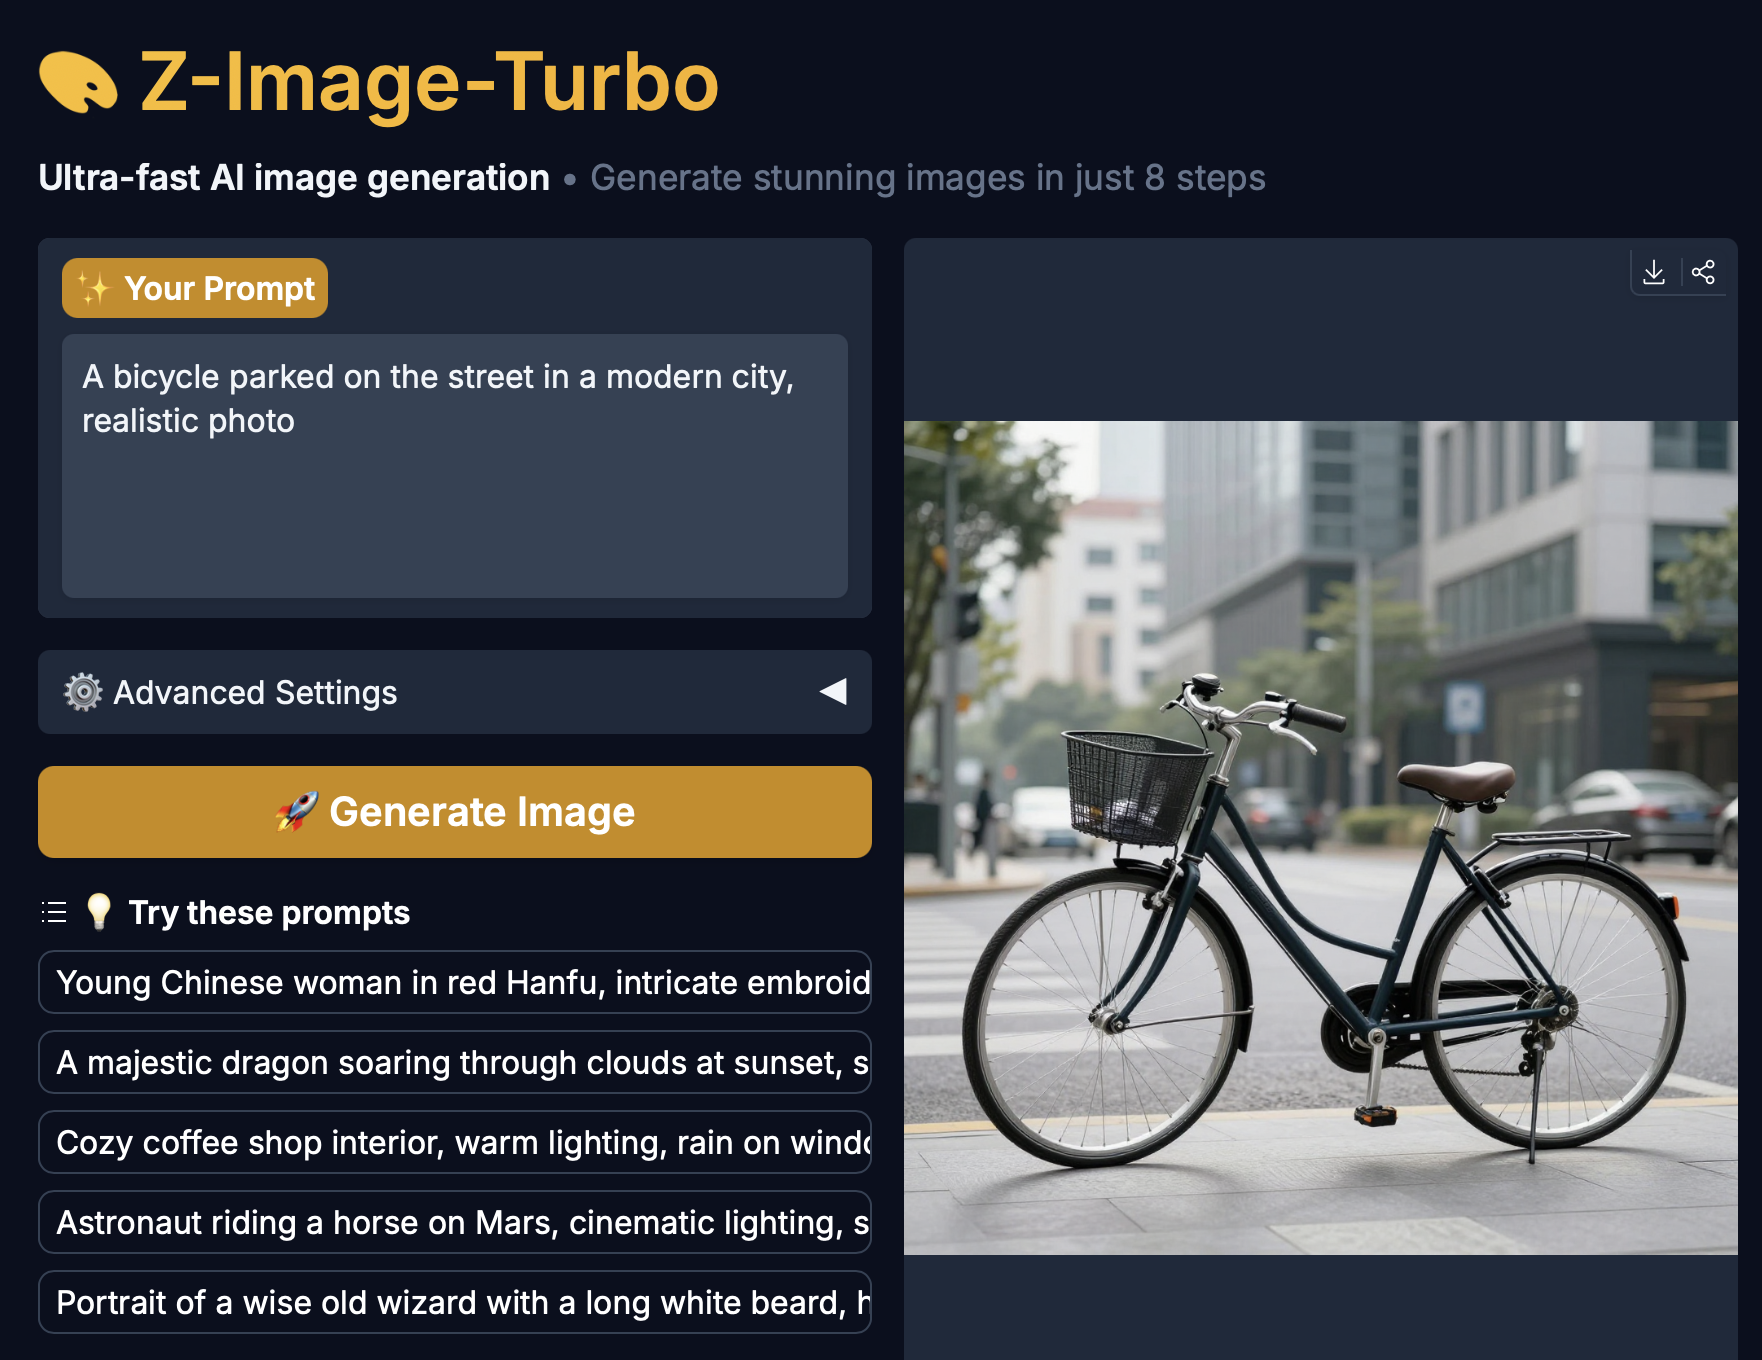